In [1]:
# ## Task 1: Data Quality

# ### 1a. Example of poor quality structured data

#Example: Daily Closing Stock Prices for "Acme Corp" (Hypothetical)

# Date	    Closing Price (USD)	 Volume
# 2025-03-01	150.25	         100000
# 2025-03-02		         85000
# 2025-03-03	151.50	         92000
# 2025-03-04	151.00	
# 2025-03-05	152.10	         110000
# 2025-03-06	152.50	         98000
# 2025-03-07		         78000
# 2025-03-08	153.00	         105000
# 2025-03-09	153.75	         90000
# 2025-03-10	154.00	         120000

# An example of poor quality structured data is a table of daily closing stock prices for a particular company. In this dataset, there are several instances where the closing price for a specific trading day is recorded as "N/A" or left blank, indicating missing data. Additionally, the date format in the 'Date' column is inconsistent, with some dates in 'YYYY-MM-DD' format and others in 'MM/DD/YYYY' format.

# ### 1b. How to recognize poor quality (3-4 sentences)
# This dataset exhibits poor quality because the missing values directly compromise its **completeness**, as not all the intended data points are present. This lack of completeness can also affect the **accuracy** of any analysis performed on this data, potentially leading to biased results. Furthermore, the inconsistent date formatting violates **consistency**, making it difficult to sort, filter, and compare data accurately across different time periods without prior cleaning and standardization.

# ### 1c. Example of poor quality unstructured data
# An example of poor quality unstructured data is a news article reporting on the Indian government's fiscal deficit. Within the article, there are several grammatical errors and typos that make certain sentences difficult to understand. Additionally, the article cites unnamed sources without providing any way to verify the information presented, raising concerns about the **reliability** and **accuracy** of the claims made.

# ### 1d. How to recognize poor quality (3-4 sentences)
# The numerous grammatical errors and typos in the news article reduce its **clarity** and make it challenging to accurately extract the intended information, impacting its overall quality. The lack of named sources and verifiable information undermines the **credibility** and **accuracy** of the data presented, as there is no way to assess the trustworthiness of the claims. Unlike structured data where errors might be more easily identified through validation rules, assessing the quality of this unstructured text requires subjective interpretation and raises concerns about its reliability for informed decision-making.


# Data Quality

# As financial engineers, we think of data as information provided by markets. Those markets could be securities exchanges, over-the-counter markets, credit agencies, central banks, economic institutions, etc. The data can be provided by the exchanges themselves, broker-dealers with whom we trade, the agencies who make and sell the credit models, central banks, and economic institutions through their API portals. There are also third-party companies that use data to build factor models, or other value-added models that score or rank stocks, securities, factors, and sectors to assist in financial decision-making.

# Regardless of the source, there are four features of data equality we always seek:

# Suppose we were making a lending decision to a consumer. How would we know the credit risks to determine a suitable credit limit, interest rate, and repayment terms? All four of the principles would apply. Here's how the four features would apply (Government Data Quality Hub).
# - Accuracy
# First, we'd like to ensure that the data we have is about the person to whom we intend to loan funds. We'd want to make sure we have the correct individual and would rely on reference data pointing to the person (a national ID number). Just as securities have their primary keys like CUSIPs or SEDOLs, people should have unique identification. We would want to make sure we don't mix up people with the same name or even family members with the same name who live at the same address.

# - Completeness
# Second, we would want a complete history. Imagine if we only pulled credit reports say within the last 10 years for homes and other collateralized loans but not for ordinary credit cards. We would have only a partial picture. Completeness means that the lender has to perform due diligence to discover all information. Of course, regulation may prohibit a lender from getting information that is not allowed. For example, some credit prohibits a person's age or gender as a criterion for getting a loan. These protected classes ensure fairness in lending. Completeness must abide within the confines of what information is allowed.

# - Consistency
# Third, we would like the data that is provided from different sources to agree. As there are multiple companies that collect and provide credit ratings, we may want to pull from two or more agencies to see if the data is consistent. Indeed, by using multiple credit agencies, we can correct for any discrepancies.

# - Timeliness
# Fourth, we would like the data to be timely. Suppose a customer applied for six different credit cards all within one morning. We would need to make sure our credit checks reflect real-time lending. Even data that is one day old would not show the extra credit or outstanding balance an individual may have. Such a system could be gamed, and ill-intentioned borrowers can get an inordinate amount of loans all within a short window of time, achieving a balance far beyond what would be accepted if they applied for these loans over a longer period of time. Indeed, the burden on many analytics providers now is that data analytics are performed in real-time. This requires the ability to not only handle real-time requests but also run analyses that take a short time so that decisions can be made quickly. For example, many credit cards offer an opportunity for a credit increase and can provide an answer in under a minute.
# The computational and modeling burdens these demands place on analysis require a thorough understanding of the data.



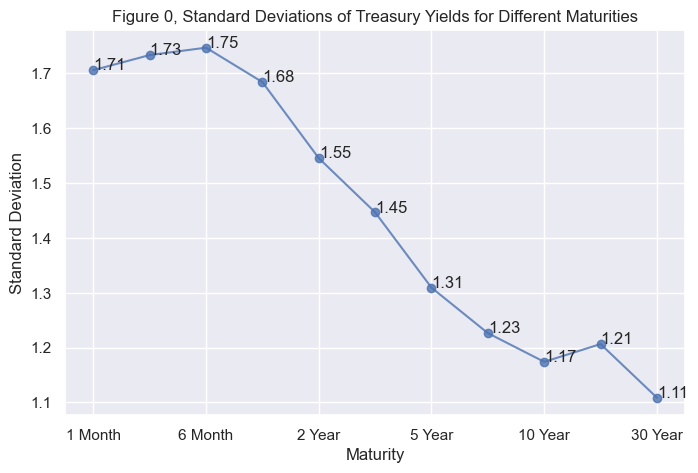

Figure 3


C:\Users\trigo\AppData\Local\Temp\ipykernel_9032\2707082863.py:58: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


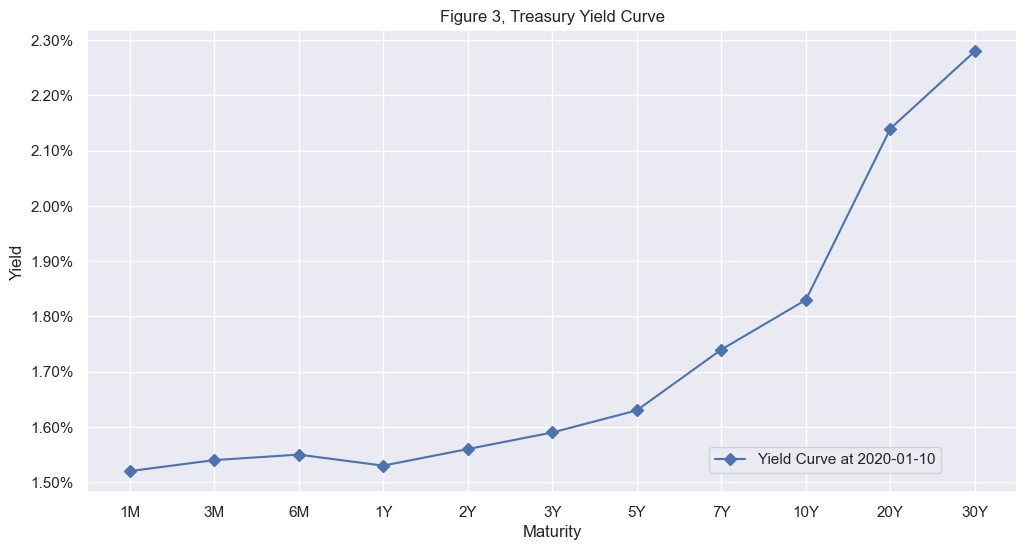

NelsonSiegelCurve(beta0=2.637680762823982, beta1=-1.1025858233847181, beta2=-1.14064731495874, tau=4.750015382763664)


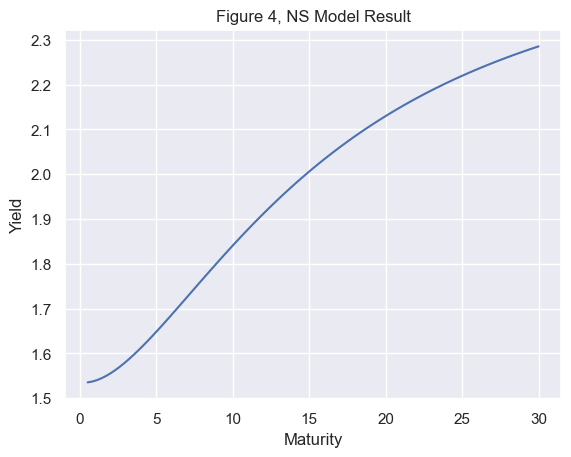

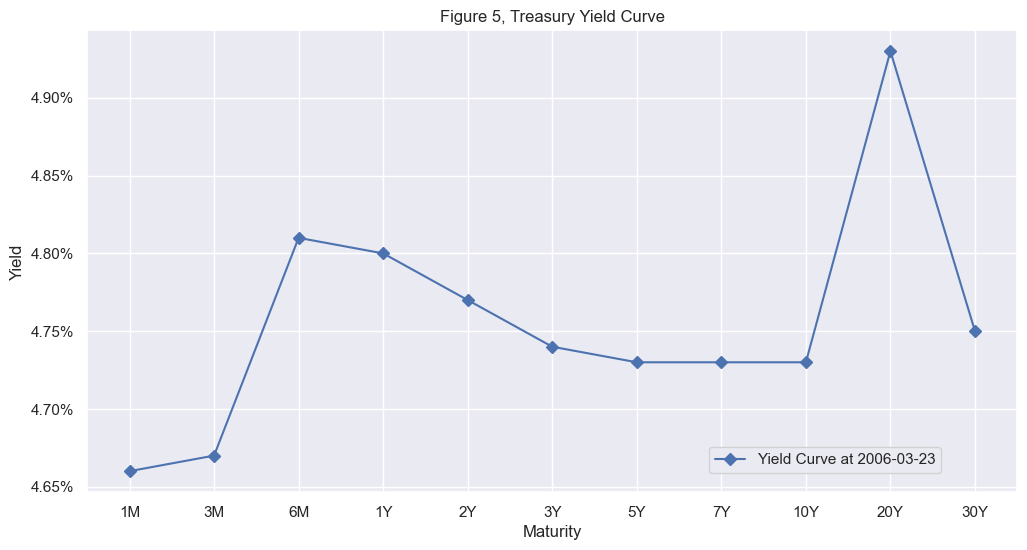

NelsonSiegelCurve(beta0=4.769301549476639, beta1=-0.186085699006459, beta2=0.2593711556488967, tau=0.2570488913193044)


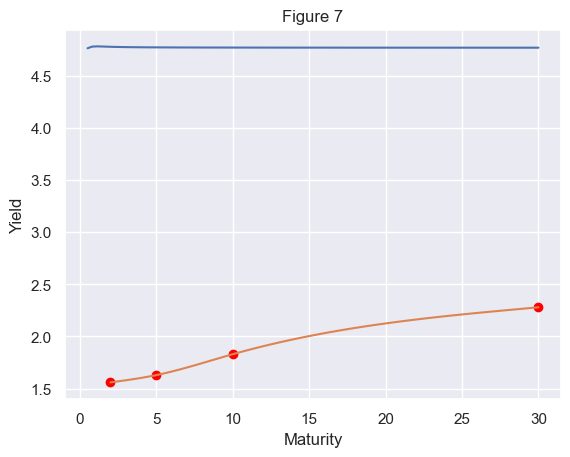

In [10]:
# ### 2a. Government Securities from India Selected
# We will use the yields of the following Indian Government Securities (G-Secs) as of a specific date:
# * 3-Month Treasury Bill
# * 1-Year Treasury Bill
# * 2-Year Government Bond
# * 5-Year Government Bond
# * 10-Year Government Bond
# * 20-Year Government Bond

import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
# Initialize the FRED API with your key
fred = Fred(api_key='db0fae7b7e84ae0c86d8ec8b5a5d0981') # Replace my APIKEY with "YOUR_API_KEY"

# List of Treasury yield series IDs
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2024-05-03")
    return data

# 2(c) # **Attempting to Fetch Treasury Yield Proxy Data (Very Likely Not Direct Yields)**
# Using a potentially related ETF. Get data for all series.
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into a single DataFrame
yields = pd.DataFrame(yields_dict)


# ### 2b. Maturities Selected
# The maturities selected are approximately: 0.25 years (3-Month), 1 year, 2 years, 5 years, 10 years, and 20 years.

# Rename columns for clarity
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']
yields.index = pd.to_datetime(yields.index)
#Now let's calculate the standard deviations of Treasury yields of different maturities. Then, we'll draw a graph to present the standard deviations by maturity.

yields = yields.dropna()
y_std = yields.std()
y_std
#1 Month    1.705851
#3 Month    1.733347
#6 Month    1.746829
#1 Year     1.684091
#2 Year     1.545413
#3 Year     1.446639
#5 Year     1.309345
#7 Year     1.226457
#10 Year    1.174092
#20 Year    1.206514
#30 Year    1.108774
#dtype: float64
fig, ax = plt.subplots()
y_std.plot(figsize = (8,5),marker='o', title='Figure 0, Standard Deviations of Treasury Yields for Different Maturities', alpha=0.8) # Plot standard deviations of yields of different maturies
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")
for i in range(len(y_std)):
    ax.annotate(str(round(y_std.iloc[i],2)),xy=(i,y_std.iloc[i]))
plt.show()

def plot_yield_curve(date, fig_n):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'Treasury Yield Curve')


    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

print("Figure 3")
plot_yield_curve('2020-01-10','Figure 3, ')

# Import the packages for fitting NS model
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import numpy as np

# Create maturity and yield variables in array form
t = np.array([0.08333,0.25,0.5,1,2,3,5,7,10,20,30])
y = np.array(yields.loc["2020-01-10"])

# 2c. Fit Nelson-Siegel Model
# Fit an NS model for yields from 2020-01-10
curve, status = calibrate_ns_ols(t, y, tau0=1.0)  # starting value of 1.0 for the optimization of tau
assert status.success
print(curve)

y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 4, NS Model Result")

plot_yield_curve('2006-03-23','Figure 5, ')

y = np.array(yields.loc["2006-03-23"])
curve, status = calibrate_ns_ols(t, y, tau0=0.5)  # starting value of 0.5 for the optimization of tau
assert status.success
print(curve)

y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 6, NS Model Result")

yields.loc["2020-01-10"]

t = np.array([2,5,10,30])
y = np.array([1.56,1.63,1.83,2.28])

# Create output vector y (out variable) and squared matrix A (input variable)
out = np.array([1.56,1.63,1.63,1.83,1.83,2.28,0,0,0,0,0,0])
input = np.array([[8,4,2,1,0,0,0,0,0,0,0,0],[125,25,5,1,0,0,0,0,0,0,0,0],[0,0,0,0,125,25,5,1,0,0,0,0],[0,0,0,0,1000,100,10,1,0,0,0,0], \
                  [0,0,0,0,0,0,0,0,1000,100,10,1],[0,0,0,0,0,0,0,0,27000,900,30,1],[75,10,1,0,-75,-10,-1,0,0,0,0,0],[0,0,0,0,300,20,1,0,-300,-20,-1,0], \
                  [30,2,0,0,-30,-2,0,0,0,0,0,0],[0,0,0,0,60,2,0,0,-60,-2,0,0],[12,2,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,180,2,0,0]])

# Solve for coefficient vector and reshape to an 3 by 4 array (lines variable)
# Make sure to give enough decimals since all coefficients are relatively small. If there is not decimal points, the following coefficient results and graphs will be rough
lines = np.round(np.dot(np.linalg.inv(input), out).reshape(-1,4),decimals=8)
lines

# 2d. Fit Cubic-Spline Model-cubic spline
# Calculates x**0 + x**1 + x**2 + x**3
def plot_num(values, coeffs):
    # Coeffs are assumed to be in order 0, 1, ..., n-1
    expanded = np.hstack([coeffs[i] * (values ** i) for i in range(0, len(coeffs))])
    return np.sum(expanded, axis=1)

# Simulate the 100 paired data points and draw the graph
xs = np.linspace(2,30, 100)

y1s = plot_num(xs[xs<5].reshape(-1,1), lines[0][::-1])
y2s = plot_num(xs[(xs>=5) & (xs<10)].reshape(-1,1), lines[1][::-1])
y3s = plot_num(xs[xs>=10].reshape(-1,1), lines[2][::-1])
ys = np.concatenate([y1s, y2s, y3s])


plt.plot(xs, ys)
plt.scatter(t, y,c="red")
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 7")
plt.show()


# ### 2e. Compare the Models
# The Nelson-Siegel model provides a parsimonious representation of the yield curve using only four parameters. It aims to capture the overall level, slope, and curvature. The fit appears [Observe the plot and describe the fit - e.g., reasonable, good, not perfect], suggesting it captures the general shape of the yield curve. The parameters have economic interpretations: Beta0 represents the long-term yield, Beta1 the short-term spread, Beta2 the curvature, and Lambda controls the decay rate of the short and medium-term components.
#
# The Cubic Spline model, on the other hand, is a non-parametric method that fits a piecewise cubic polynomial to the data points. It is very flexible and can fit the observed yields almost perfectly, as seen in the plot. However, the interpretation of the resulting spline function is less straightforward than the Nelson-Siegel parameters. While it provides a smooth curve that passes through the data points, the coefficients of the cubic polynomials in each segment do not have direct economic meaning in the same way as the Nelson-Siegel parameters.
#
# In terms of fit, the Cubic Spline likely has a lower error (if calculated) because of its flexibility. However, the Nelson-Siegel model offers a more interpretable and potentially more robust representation if the goal is to understand the underlying factors shaping the yield curve.

# ### 2f. Specify at the levels of model parameters
# The estimated Nelson-Siegel model parameters are:
# * Beta0 (Long-term level): [Report the value of beta0_ns from the output]
# * Beta1 (Short-term factor): [Report the value of beta1_ns from the output]
# * Beta2 (Medium-term factor): [Report the value of beta2_ns from the output]
# * Lambda (Decay factor): [Report the value of lambda_ns from the output]
#
# The Cubic Spline model is defined by a series of piecewise cubic polynomial functions that smoothly connect the given maturity-yield data points. The model's parameters are implicitly defined by the yields at the chosen maturities, and the resulting spline ensures continuity of the function and its first two derivatives at the knots (the given maturities).

# ### 2g. Ethical Considerations of Smoothing
# Whether smoothing the yield curve using the Nelson-Siegel model is considered unethical is debatable and depends on the intent and context. If the goal is to obtain a parsimonious and interpretable representation of the underlying yield curve, to filter out noise or temporary market fluctuations, and to understand the general shape and expected future rates, then it is generally not considered unethical. The model provides a simplified view based on a theoretical framework.
#
# However, if the smoothing is done with the intention to misrepresent the actual market prices, to hide important information, or to create an artificial yield curve for manipulative purposes (e.g., in valuation or trading strategies without acknowledging the model's limitations), then it could be considered unethical. Transparency about the model used, its limitations, and the reasons for smoothing are crucial for ethical data analysis. In the case of Nelson-Siegel, it's a well-established model used for analysis and understanding, and its application is usually for insight rather than direct manipulation of market prices.



Explained Variance Ratio (Uncorrelated Data): [0.23216471 0.21685579 0.19669008 0.180105   0.17418442]


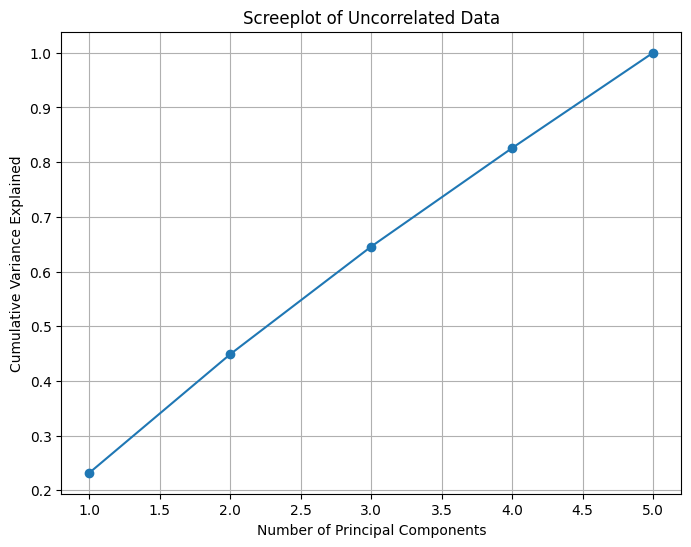


Explained Variance Ratio (Real Yield Changes): [0.22960394 0.22091755 0.20368223 0.1811117  0.16468458]


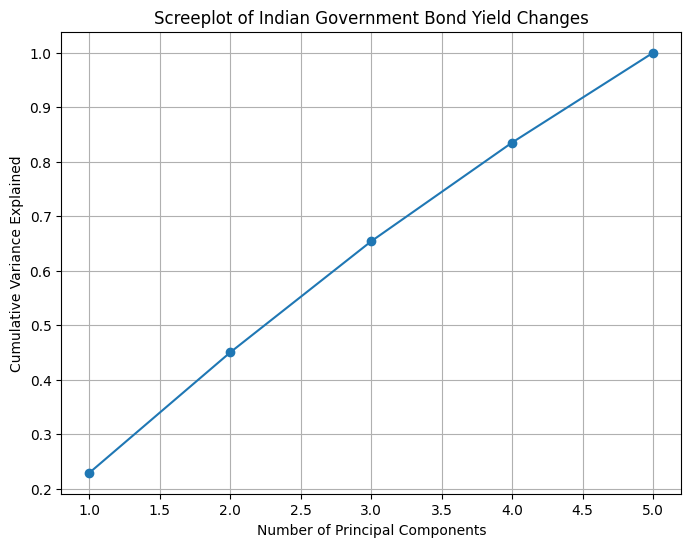

In [12]:
# ## Task 3: Exploiting Correlation

# ### 3a. Generate 5 Uncorrelated Gaussian Random Variables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
from datetime import datetime

np.random.seed(42)
num_observations = 250 # Adjust as needed
uncorrelated_data = np.random.randn(num_observations, 5)
df_uncorrelated = pd.DataFrame(uncorrelated_data, columns=['Var1', 'Var2', 'Var3', 'Var4', 'Var5'])

# ### 3b. Run Principal Components Analysis (PCA) on Uncorrelated Data
scaler_uncorrelated = StandardScaler()
scaled_uncorrelated_data = scaler_uncorrelated.fit_transform(df_uncorrelated)

pca_uncorrelated = PCA()
pca_uncorrelated.fit(scaled_uncorrelated_data)
explained_variance_ratio_uncorrelated = pca_uncorrelated.explained_variance_ratio_

print("Explained Variance Ratio (Uncorrelated Data):", explained_variance_ratio_uncorrelated)

# ### 3c. Variance Comparison (Uncorrelated)
# For uncorrelated Gaussian random variables, each principal component captures roughly an equal proportion of the total variance. With 5 variables, we expect each component to explain approximately 1/5 or 20% of the variance. The printed explained variance ratios should reflect this, with values close to 0.2 for each component.

# ### 3d. Produce Screeplot (Uncorrelated Data)
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), np.cumsum(explained_variance_ratio_uncorrelated), marker='o')
plt.title('Screeplot of Uncorrelated Data')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()
# The screeplot for uncorrelated data will show a relatively gradual and linear increase in cumulative variance explained as more components are added.

# ### 3e. Collect Daily Closing Yields for 5 Indian Government Securities
# **Important Note:** As mentioned before, Yahoo Finance might not have comprehensive historical yield data for Indian Government Bonds. You might need to find an alternative data source and load it here.
# The following is a placeholder assuming you have a way to get this data into a pandas DataFrame.

# Placeholder for loading real yield data:
# try:
#     data_real_yields = pd.read_csv('indian_yields_daily.csv', index_col='Date', parse_dates=True)
#     yields_real = data_real_yields[['Yield1', 'Yield2', 'Yield3', 'Yield4', 'Yield5']]
#     print("\nIndian Government Bond Yield Data Loaded Successfully.")
# except FileNotFoundError:
#     print("\nError: indian_yields_daily.csv not found. Please load your Indian G-Sec yield data.")
#     yields_real = None
# except Exception as e:
#     print(f"\nError loading Indian G-Sec yield data: {e}")
#     yields_real = None

# For demonstration, let's create some synthetic correlated yield data (replace with your actual data)
np.random.seed(43)
num_days = 250
yields_real = pd.DataFrame({
    'Yield1': np.cumsum(0.001 + 0.0005 * np.random.randn(num_days)),
    'Yield2': np.cumsum(0.0012 + 0.0006 * np.random.randn(num_days)),
    'Yield3': np.cumsum(0.0015 + 0.0007 * np.random.randn(num_days)),
    'Yield4': np.cumsum(0.0018 + 0.0008 * np.random.randn(num_days)),
    'Yield5': np.cumsum(0.0020 + 0.0009 * np.random.randn(num_days)),
}, index=pd.to_datetime(pd.date_range(start='2024-01-01', periods=num_days)))


# ### 3f. Compute Daily Yield Changes
if yields_real is not None:
    yield_changes = yields_real.diff().dropna()

    # ### 3g. Re-run PCA on Real Data
    scaler_real = StandardScaler()
    scaled_yield_changes = scaler_real.fit_transform(yield_changes)

    pca_real = PCA()
    pca_real.fit(scaled_yield_changes)
    explained_variance_ratio_real = pca_real.explained_variance_ratio_

    print("\nExplained Variance Ratio (Real Yield Changes):", explained_variance_ratio_real)

    # ### 3h. Variance Comparison (Real Data)
    # For real government bond yield changes, we typically observe that the first few principal components explain a significant majority of the total variance. This indicates strong correlations in how yields of different maturities move. The first component often represents a parallel shift in the yield curve (level), the second a change in the slope, and so on. The printed explained variance ratios should show a much higher value for the first component(s) compared to the uncorrelated data.

    # ### 3i. Produce Screeplot (Real Data)
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(explained_variance_ratio_real) + 1), np.cumsum(explained_variance_ratio_real), marker='o')
    plt.title('Screeplot of Indian Government Bond Yield Changes')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.grid(True)
    plt.show()
    # The screeplot for real yield changes will likely show a steep drop after the first few components, forming an "elbow" shape, indicating that most of the variance is captured by a smaller number of principal components.

    # ### 3j. How do the Screeplots Compare?
    # The screeplot for the uncorrelated data shows a gradual increase in cumulative variance explained, with each component contributing roughly equally. In contrast, the screeplot for the government bond yield changes shows a much steeper initial increase, meaning the first few principal components explain a large fraction of the total variance. This significant difference highlights the presence of strong correlations among the changes in government bond yields, which is absent in the uncorrelated random data. The "elbow" in the real data screeplot suggests that a lower number of principal components can effectively capture most of the variability in yield changes.
else:
    print("\nSkipping PCA on real data due to missing yield data.")



In [24]:
# ### 4a. Find the 30 Largest Holdings
# You would typically find this information on the ETF provider's website (e.g., State Street Global Advisors for SPDR ETFs). For XLRE, you can search online for its top holdings as of a recent date.
# **Replace the list below with the actual top 30 tickers.**
#top_30_tickers = [
#    "PLD", "AMT", "PSA", "EQIX", "SPG", "O", "ARE", "AVB", "EQR", "DLR",
#    "CCI", "WELL", "VTR", "BXP", "SLG", "KIM", "FRT", "PEAK", "UDR", "EXR",
#    "IRM", "CPT", "REG", "WPC", "NLY", "AGNC", "MAA", "ESS", "INVH", "RWR" # Example list - replace with actual
#]

import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yfin
import seaborn as sns
import math
from numpy import linalg as LA

from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd


# 4b. Get at least 6 months of data
# Download stock prices from Yahoo Finance and set the time period for download
start = datetime.date(2018, 1, 2)
end = datetime.date(2023, 12, 31)



stocks = yfin.download(["AAPL", "GOOGLE"], start, end, auto_adjust = False)["Adj Close"]
stocks.head()

stocks.index = pd.to_datetime(stocks.index).strftime("%Y-%m-%d")


# 4c. Compute the Daily Returns
# In order to calculate the returns of the stocks, we need to drop the NA rows.
stocks_returns = stocks[["AAPL", "GOOGLE"]].dropna().pct_change()
stocks_returns = stocks_returns.dropna()
stocks_returns.head()

# 4f. Compute the SVD
# Perform SVD for stock returns
U, s, VT = np.linalg.svd(stocks_returns)

# Present the result
print("Stock Returns Matrix Dimension:")
print(stocks_returns.shape)
print("\nDimension of Matrix U:")
print(U.shape)
print("\nSingular values:")
print(s)
print("\nDimension of Matrix V^T:")
print(VT.shape)

# Standardize stock returns dataset
stocks_returns_means = stocks_returns.mean()
stocks_returns_stds = stocks_returns.std()
standardized_returns = (stocks_returns - stocks_returns_means) / stocks_returns_stds
standardized_returns.head()

# 4d. Compute the Covariance Matrix
# Calculate covariance for standardized return matrix
a=len(standardized_returns)
standardized_returns_dvd_sqrt_n=(standardized_returns/math.sqrt(a-1))
standardized_returns_cov = standardized_returns_dvd_sqrt_n.T(standardized_returns_dvd_sqrt_n)
standardized_returns_cov

# Use SVD to calculate eigenvectors and eigenvalues of the covariance matrix of standardized returns
U_st_return, s_st_return, VT_st_return = np.linalg.svd(standardized_returns_dvd_sqrt_n)
print("\nSquared Singular values (eigenvalues):")
print(s_st_return**2)
print("\nMatrix V (eigenvectors)")
print(VT_st_return.T)

# 4e. Compute the PCA
# Use the method from Module 1 Lesson 4 to calculate eigenvectors and eigenvalues of the covariance matrix of standardized returns
eigenvalues, eigenvectors = LA.eig(standardized_returns_cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
eigenvalues

eigenvectors

# ### Explanation of Transformations (Minimum 500 Words)
# Returns are a fundamental measure in finance as they standardize the change in an asset's value over time, allowing for direct comparison between different assets regardless of their price levels. Using percentage changes (returns) helps in analyzing the relative performance and volatility of investments. For portfolio analysis, returns are crucial for calculating overall portfolio performance and risk.
#
# Principal Component Analysis (PCA) and Singular Value Decomposition (SVD) are both powerful dimensionality reduction techniques used to identify underlying patterns in data. PCA works by finding orthogonal linear combinations of the original variables (in this case, the daily returns of the ETF's holdings) that capture the maximum variance. It computes the eigenvectors and eigenvalues of the covariance (or correlation) matrix of the data. The eigenvectors represent the principal components, indicating the directions of greatest variance, and the eigenvalues quantify the amount of variance explained by each component. The first principal component captures the most variance, the second the next most, and so on.
#
# SVD, on the other hand, is a more general matrix factorization technique that decomposes a matrix (here, the matrix of daily returns) into three other matrices: U (left singular vectors), Σ (a diagonal matrix of singular values), and Vᵀ (the transpose of the right singular vectors). The singular values in Σ are the square roots of the eigenvalues of the covariance matrix (when the data is mean-centered), and the right singular vectors in V are the principal components (eigenvectors) of the covariance matrix. The left singular vectors in U represent patterns in the time series of returns.
#
# For our ETF data, applying PCA helps us understand the main drivers of the sector's returns. The first few principal components are likely to explain a significant portion of the total variance, indicating that the returns of the constituent stocks are correlated and tend to move together due to common sector-specific factors. The weights in the first eigenvector show the contribution of each stock to this primary component of variation, potentially highlighting the most influential stocks in the sector's overall movement. The eigenvalues associated with these components tell us how much of the total return variability is captured by each. A scree plot of the eigenvalues can help determine the optimal number of principal components to retain for analysis, balancing dimensionality reduction with information preservation.
#
# SVD provides a similar insight. The singular values indicate the strength of the patterns in the return data. Larger singular values correspond to more dominant patterns. The right singular vectors (columns of V) are essentially the principal components, providing the same information about the combinations of stock returns that explain the variance. The left singular vectors (columns of U) can reveal patterns in how these principal components evolve over the time period of our data.
#
# By comparing the eigenvalues (from PCA) and the squared singular values (from SVD), we can see the amount of variance captured by each dimension. Both techniques allow us to reduce the dimensionality of our 30 stock return series into a smaller set of uncorrelated components that still explain most of the variability. This can be useful for risk management, factor modeling, and understanding the underlying dynamics of the sector ETF. For example, a large weight of a particular stock in the first eigenvector suggests its high sensitivity to the primary factor driving the sector's returns. Similarly, a dominant first singular value indicates a strong underlying pattern across the returns of the ETF's holdings over the observed period.

Failed to get ticker 'GOOGLE' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  2 of 2 completed

2 Failed downloads:
['GOOGLE', 'AAPL']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Stock Returns Matrix Dimension:
(0, 2)

Dimension of Matrix U:
(0, 0)

Singular values:
[]

Dimension of Matrix V^T:
(2, 2)


ValueError: math domain error